# ISS Speed Analysis from Astro Pi Data

This notebook analyzes data from the Astro Pi mission to:
1. Calculate ISS speed from GPS coordinates
2. Explore correlations between ISS speed and various sensor measurements
3. Visualize relationships through comprehensive plots

In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Configure display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# Load the CSV data
df = pd.read_csv('AstroPI_CSV.csv')

# Convert Date/Time to datetime
df['Date/Time'] = pd.to_datetime(df['Date/Time'])

# Display basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst few rows:")
df.head()

Dataset Shape: (13723, 21)

Column Names:
['Date/Time', 'Latitude', 'Longitude', 'Temperature', 'Humidity', 'Pressure', 'Compass', 'MagX', 'MagY', 'MagZ', 'Pitch', 'Roll', 'Yaw', 'AccelX', 'AccelY', 'AccelZ', 'R', 'G', 'B', 'C', 'Motion']

First few rows:


,Date/Time,Latitude,Longitude,Temperature,Humidity,Pressure,Compass,MagX,MagY,MagZ,Pitch,Roll,Yaw,AccelX,AccelY,AccelZ,R,G,B,C,Motion
0,2022-01-31 12:21:15,6.833,152.032,32.7,57.5,1013.6,117.0,-5.4,-10.6,-4.4,0,360,117,0,0.0,0,29,27,24,84,1
1,2022-01-31 12:21:20,6.567,152.223,32.9,57.7,1013.6,117.1,-11.7,-21.7,-8.9,0,360,117,0,0.0,0,29,28,24,85,1
2,2022-01-31 12:21:25,6.308,152.409,32.7,57.6,1013.6,117.1,-14.0,-26.1,-11.8,0,360,117,0,0.0,0,29,28,24,87,1
3,2022-01-31 12:21:30,6.048,152.595,32.8,58.0,1013.6,117.2,-14.9,-27.8,-12.2,0,360,117,0,0.0,0,29,27,24,85,1
4,2022-01-31 12:21:35,5.789,152.780,32.7,57.8,1013.6,117.2,-15.4,-28.7,-12.4,0,360,117,0,0.0,0,29,27,24,85,1


In [5]:
# Data overview and statistics
print("Dataset Info:")
print(df.info())
print("\n" + "="*50)
print("\nBasic Statistics:")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13723 entries, 0 to 13722
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date/Time    13723 non-null  datetime64[ns]
 1   Latitude     13723 non-null  float64       
 2   Longitude    13723 non-null  float64       
 3   Temperature  13723 non-null  float64       
 4   Humidity     13723 non-null  float64       
 5   Pressure     13723 non-null  float64       
 6   Compass      13723 non-null  float64       
 7   MagX         13723 non-null  float64       
 8   MagY         13723 non-null  float64       
 9   MagZ         13723 non-null  float64       
 10  Pitch        13723 non-null  int64         
 11  Roll         13723 non-null  int64         
 12  Yaw          13723 non-null  int64         
 13  AccelX       13723 non-null  int64         
 14  AccelY       13723 non-null  float64       
 15  AccelZ       13723 non-null  int64     

,Date/Time,Latitude,Longitude,Temperature,Humidity,Pressure,Compass,MagX,MagY,MagZ,Pitch,Roll,Yaw,AccelX,AccelY,AccelZ,R,G,B,C,Motion
count,13723,13723.000000,13723.000000,13723.000000,13723.000000,13723.000000,13723.000000,13723.000000,13723.000000,13723.000000,13723.000000,13723.000000,13723.000000,13723.0,13723.000000,13723.0,13723.000000,13723.000000,13723.000000,13723.000000,13723.000000
mean,2022-01-31 22:06:15.925745152,-1.269351,-0.699155,33.707221,56.429214,1012.561677,85.215361,1.284362,-13.731582,-3.914611,341.263936,352.027472,85.264374,0.0,0.000058,0.0,14.006048,12.638782,11.078263,39.958464,0.996356
min,2022-01-31 12:21:15,-51.797000,-179.914000,32.700000,53.400000,1011.700000,0.000000,-31.600000,-31.500000,-44.200000,0.000000,0.000000,0.000000,0.0,-0.100000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2022-01-31 17:13:45.500000,-34.850000,-89.731000,33.500000,56.200000,1012.000000,25.400000,-14.900000,-17.700000,-21.900000,343.000000,356.000000,25.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,1.000000
50%,2022-01-31 22:06:16,-2.423000,-2.643000,33.700000,56.500000,1012.400000,93.200000,0.800000,-13.200000,-6.700000,350.000000,357.000000,93.000000,0.0,0.000000,0.0,8.000000,3.000000,3.000000,15.000000,1.000000
75%,2022-02-01 02:58:46.500000,32.262000,89.143000,34.000000,56.600000,1013.200000,125.950000,19.500000,-9.100000,18.500000,353.000000,358.000000,126.000000,0.0,0.000000,0.0,29.000000,27.000000,24.000000,84.000000,1.000000
max,2022-02-01 07:51:17,51.798000,179.986000,34.300000,59.700000,1013.700000,360.000000,30.700000,1.500000,34.200000,360.000000,360.000000,360.000000,0.0,0.100000,0.0,30.000000,29.000000,25.000000,89.000000,1.000000
std,NaN,35.095468,103.225765,0.296950,0.385308,0.634679,63.675329,18.158454,6.891451,22.579747,51.233038,42.728582,63.757332,0.0,0.010999,0.0,13.257857,12.946428,11.284588,39.559838,0.060254


In [6]:
# Check for missing values
print("Missing values per column:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values!")
print("\nData time range:")
print(f"Start: {df['Date/Time'].min()}")
print(f"End: {df['Date/Time'].max()}")
print(f"Duration: {df['Date/Time'].max() - df['Date/Time'].min()}")

Missing values per column:
No missing values!

Data time range:
Start: 2022-01-31 12:21:15
End: 2022-02-01 07:51:17
Duration: 0 days 19:30:02


In [7]:
# Function to calculate distance between two GPS coordinates using Haversine formula
def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculate the great circle distance between two points on Earth (in km)
    """
    R = 6371  # Earth radius in kilometers
    
    # Convert to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    distance = R * c
    
    return distance

# Calculate time differences between consecutive measurements (in seconds)
df['Time_Diff'] = df['Date/Time'].diff().dt.total_seconds()

# Calculate distance between consecutive GPS points
df['Distance_km'] = haversine_distance(
    df['Latitude'].shift(1), 
    df['Longitude'].shift(1),
    df['Latitude'], 
    df['Longitude']
)

# Calculate speed in km/s and convert to km/h
df['Speed_km_s'] = df['Distance_km'] / df['Time_Diff']
df['Speed_km_h'] = df['Speed_km_s'] * 3600  # Convert to km/h
df['Speed_m_s'] = df['Speed_km_s'] * 1000   # Convert to m/s

# Remove first row (NaN values from diff operations)
df = df.dropna(subset=['Speed_km_h'])

print("Speed calculation complete!")
print(f"\nSpeed Statistics:")
print(df[['Speed_km_h', 'Speed_m_s']].describe())

Speed calculation complete!

Speed Statistics:


         Speed_km_h     Speed_m_s
count  13722.000000  13722.000000
mean   24894.007027   6915.001952
std     1358.722567    377.422935
min    20865.305575   5795.918215
25%    25240.985380   7011.384828
50%    25376.286772   7048.968548
75%    25465.600628   7073.777952
max    26156.629553   7265.730431


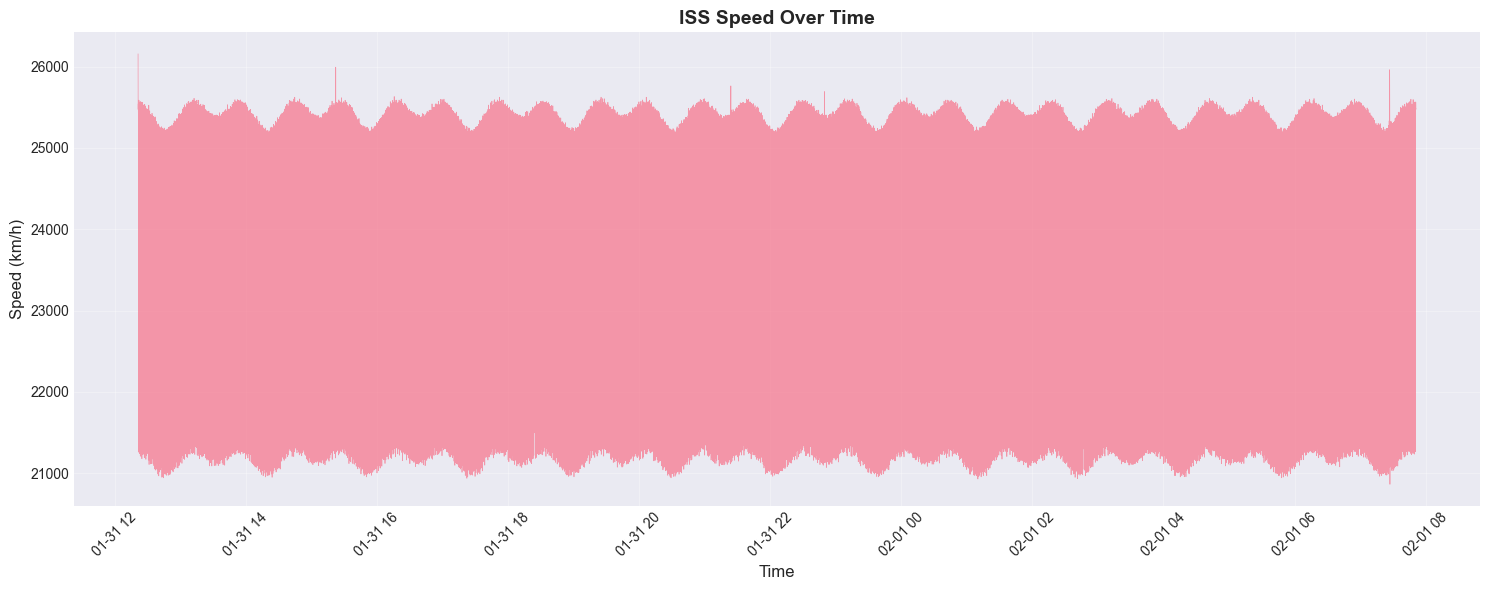

Average ISS Speed: 24894.01 km/h (6915.00 m/s)
Max Speed: 26156.63 km/h
Min Speed: 20865.31 km/h


In [8]:
# Plot 1: ISS Speed over Time
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(df['Date/Time'], df['Speed_km_h'], linewidth=0.5, alpha=0.7)
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Speed (km/h)', fontsize=12)
ax.set_title('ISS Speed Over Time', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Average ISS Speed: {df['Speed_km_h'].mean():.2f} km/h ({df['Speed_m_s'].mean():.2f} m/s)")
print(f"Max Speed: {df['Speed_km_h'].max():.2f} km/h")
print(f"Min Speed: {df['Speed_km_h'].min():.2f} km/h")

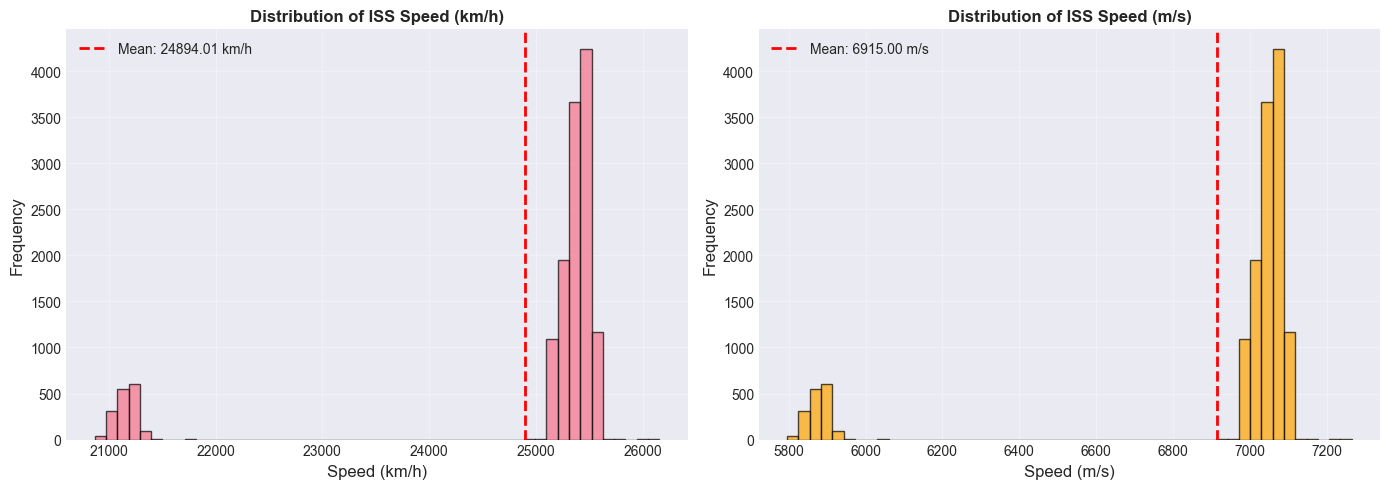

In [9]:
# Plot 2: Speed Distribution Histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Speed_km_h'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Speed (km/h)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of ISS Speed (km/h)', fontsize=12, fontweight='bold')
axes[0].axvline(df['Speed_km_h'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["Speed_km_h"].mean():.2f} km/h')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(df['Speed_m_s'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Speed (m/s)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of ISS Speed (m/s)', fontsize=12, fontweight='bold')
axes[1].axvline(df['Speed_m_s'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["Speed_m_s"].mean():.2f} m/s')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

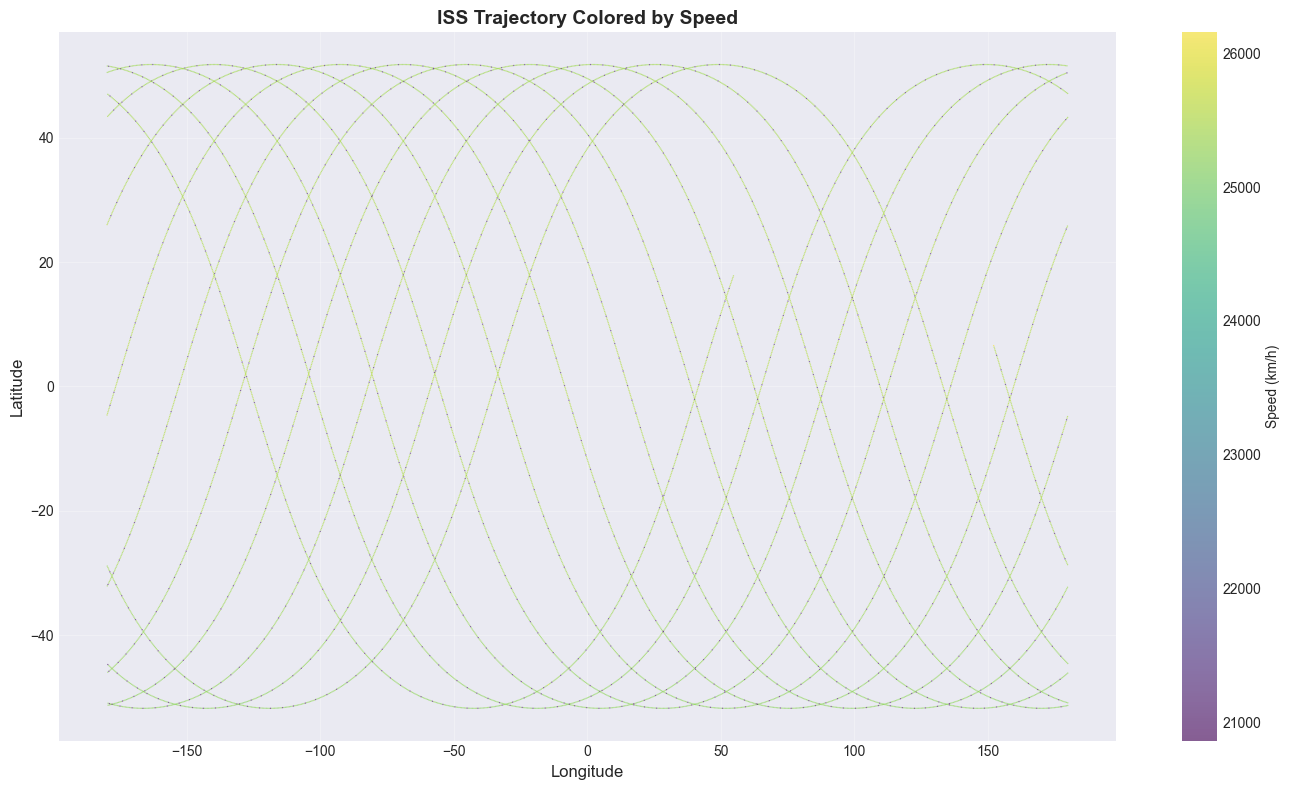

In [10]:
# Plot 3: ISS Trajectory (Latitude vs Longitude) colored by Speed
fig, ax = plt.subplots(figsize=(14, 8))
scatter = ax.scatter(df['Longitude'], df['Latitude'], 
                     c=df['Speed_km_h'], cmap='viridis', 
                     s=1, alpha=0.6, edgecolors='none')
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title('ISS Trajectory Colored by Speed', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Speed (km/h)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

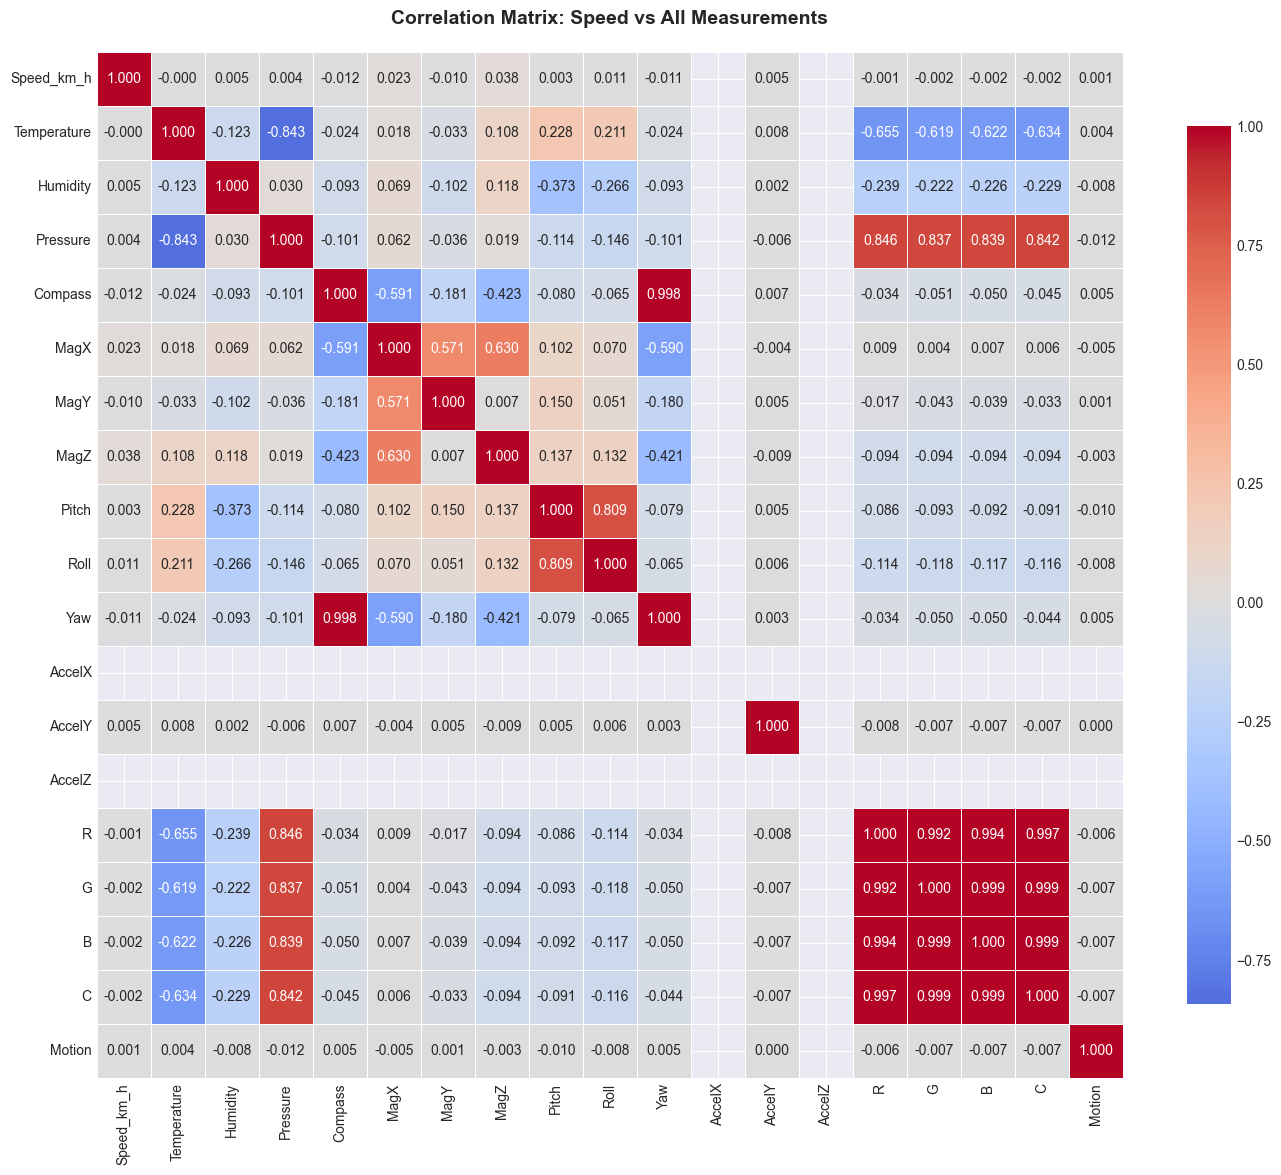

In [11]:
# Calculate correlation matrix with speed
numeric_cols = ['Speed_km_h', 'Temperature', 'Humidity', 'Pressure', 'Compass', 
                'MagX', 'MagY', 'MagZ', 'Pitch', 'Roll', 'Yaw', 
                'AccelX', 'AccelY', 'AccelZ', 'R', 'G', 'B', 'C', 'Motion']

correlation_matrix = df[numeric_cols].corr()

# Plot 4: Correlation Heatmap
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Correlation Matrix: Speed vs All Measurements', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Correlations with ISS Speed (sorted by absolute value):
MagZ           :  0.0377
MagX           :  0.0226
Roll           :  0.0106
Humidity       :  0.0053
AccelY         :  0.0051
Pressure       :  0.0042
Pitch          :  0.0030
Motion         :  0.0013
Temperature    : -0.0004
R              : -0.0014
C              : -0.0016
B              : -0.0016
G              : -0.0017
MagY           : -0.0101
Yaw            : -0.0112
Compass        : -0.0116
AccelX         :     nan
AccelZ         :     nan


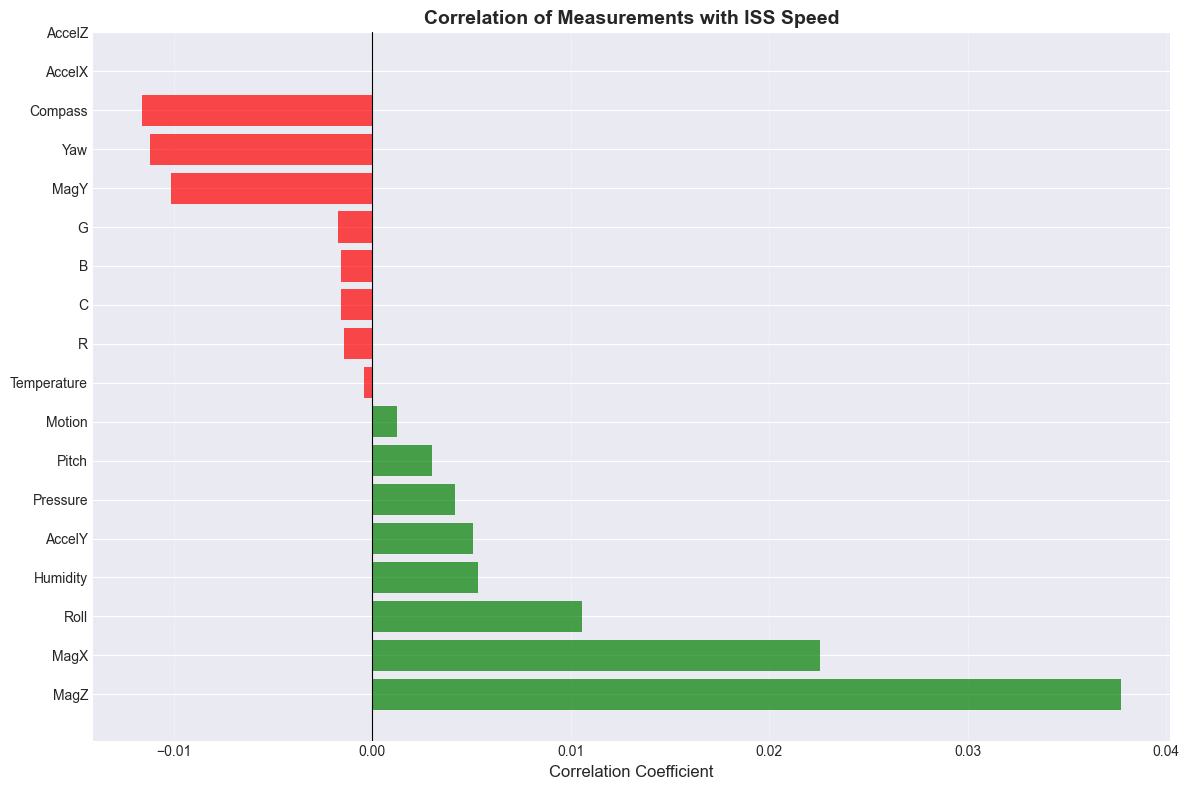

In [12]:
# Extract correlations with speed
speed_correlations = correlation_matrix['Speed_km_h'].drop('Speed_km_h').sort_values(ascending=False)

print("Correlations with ISS Speed (sorted by absolute value):")
print("="*60)
for col, corr in speed_correlations.items():
    print(f"{col:15s}: {corr:7.4f}")

# Plot 5: Bar plot of correlations with speed
fig, ax = plt.subplots(figsize=(12, 8))
colors = ['red' if x < 0 else 'green' for x in speed_correlations.values]
ax.barh(range(len(speed_correlations)), speed_correlations.values, color=colors, alpha=0.7)
ax.set_yticks(range(len(speed_correlations)))
ax.set_yticklabels(speed_correlations.index)
ax.set_xlabel('Correlation Coefficient', fontsize=12)
ax.set_title('Correlation of Measurements with ISS Speed', fontsize=14, fontweight='bold')
ax.axvline(0, color='black', linestyle='-', linewidth=0.8)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

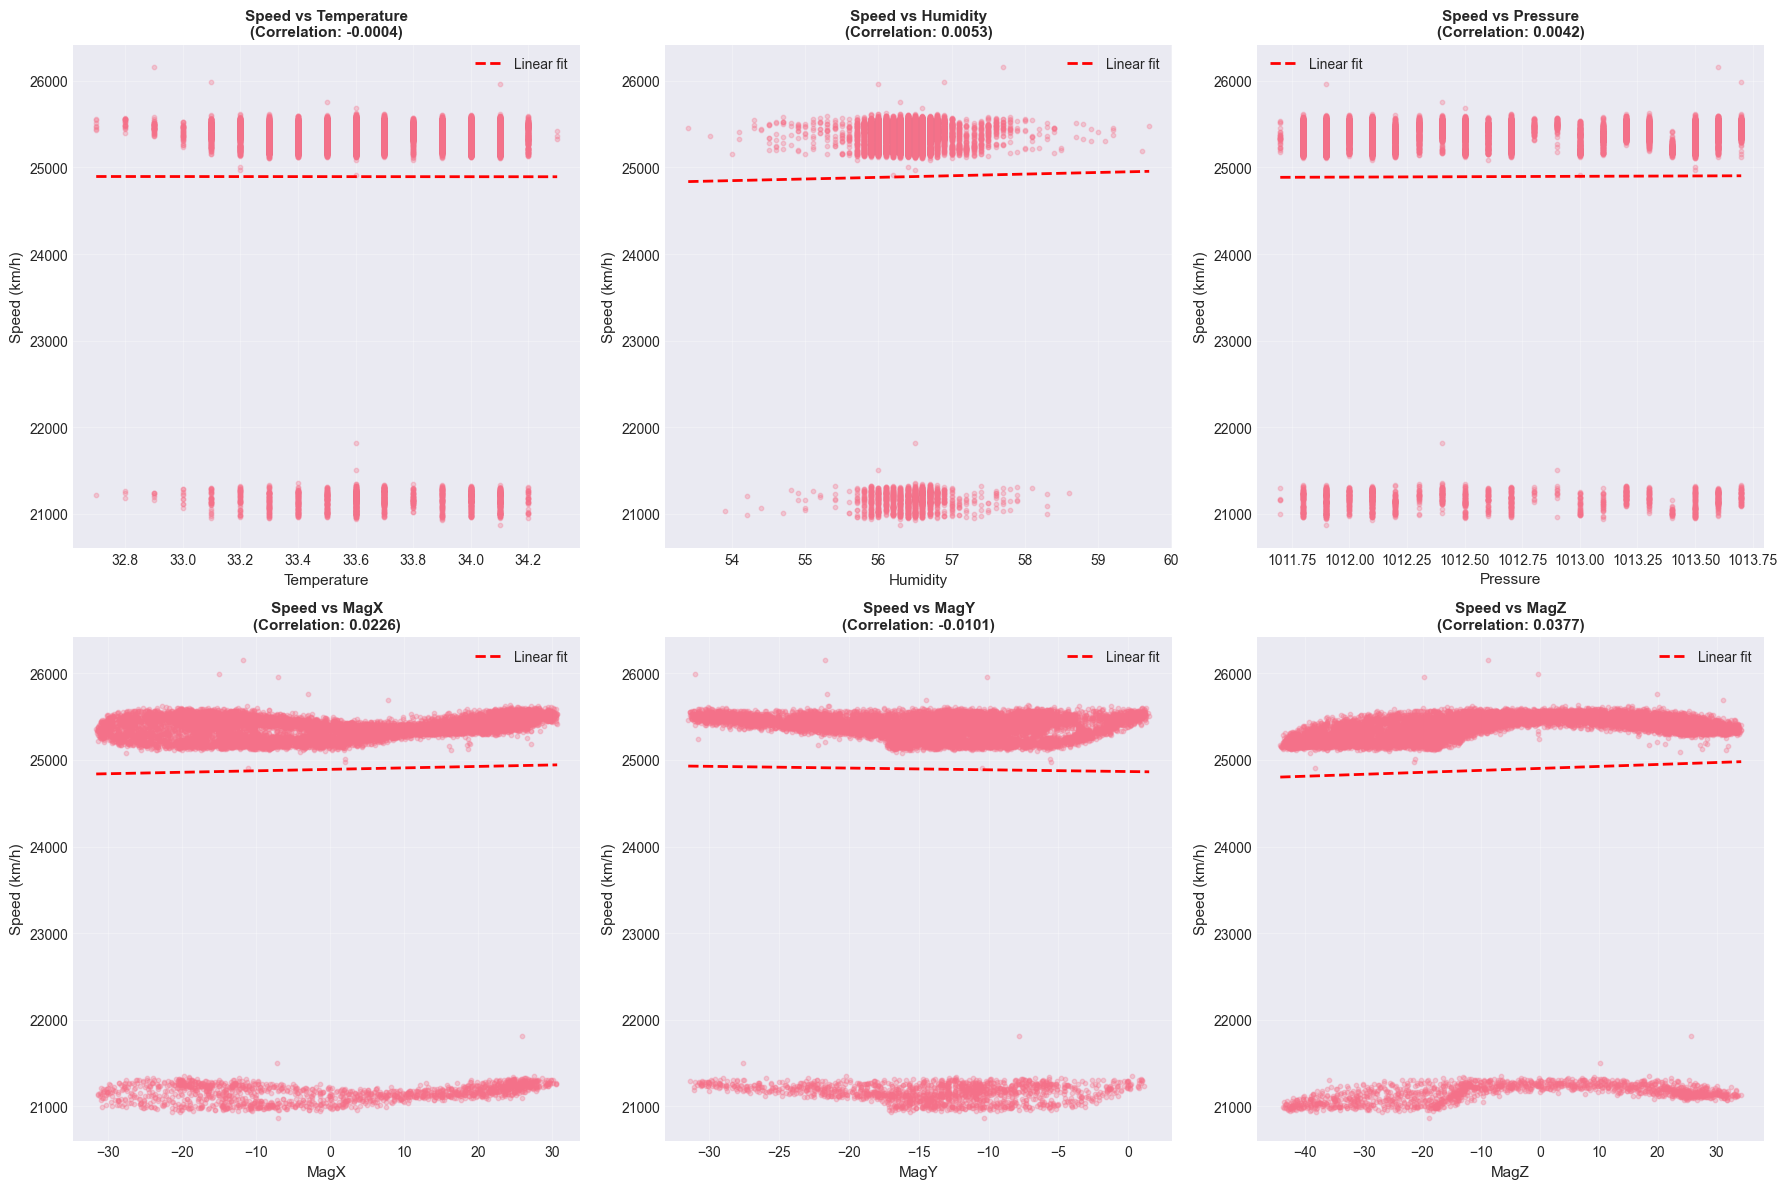

In [13]:
# Plot 6-10: Scatter plots of Speed vs Key Measurements with regression lines
measurements = ['Temperature', 'Humidity', 'Pressure', 'MagX', 'MagY', 'MagZ', 
                'Pitch', 'Roll', 'Yaw', 'Compass']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, meas in enumerate(measurements[:6]):
    ax = axes[idx]
    
    # Create scatter plot
    ax.scatter(df[meas], df['Speed_km_h'], alpha=0.3, s=10)
    
    # Add regression line
    z = np.polyfit(df[meas], df['Speed_km_h'], 1)
    p = np.poly1d(z)
    ax.plot(df[meas].sort_values(), p(df[meas].sort_values()), 
            "r--", linewidth=2, label=f'Linear fit')
    
    # Calculate and display correlation
    corr = df[meas].corr(df['Speed_km_h'])
    ax.set_xlabel(f'{meas}', fontsize=11)
    ax.set_ylabel('Speed (km/h)', fontsize=11)
    ax.set_title(f'Speed vs {meas}\n(Correlation: {corr:.4f})', fontsize=11, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Hide the last subplot if we have odd number
if len(measurements) < 6:
    axes[-1].axis('off')

plt.tight_layout()
plt.show()

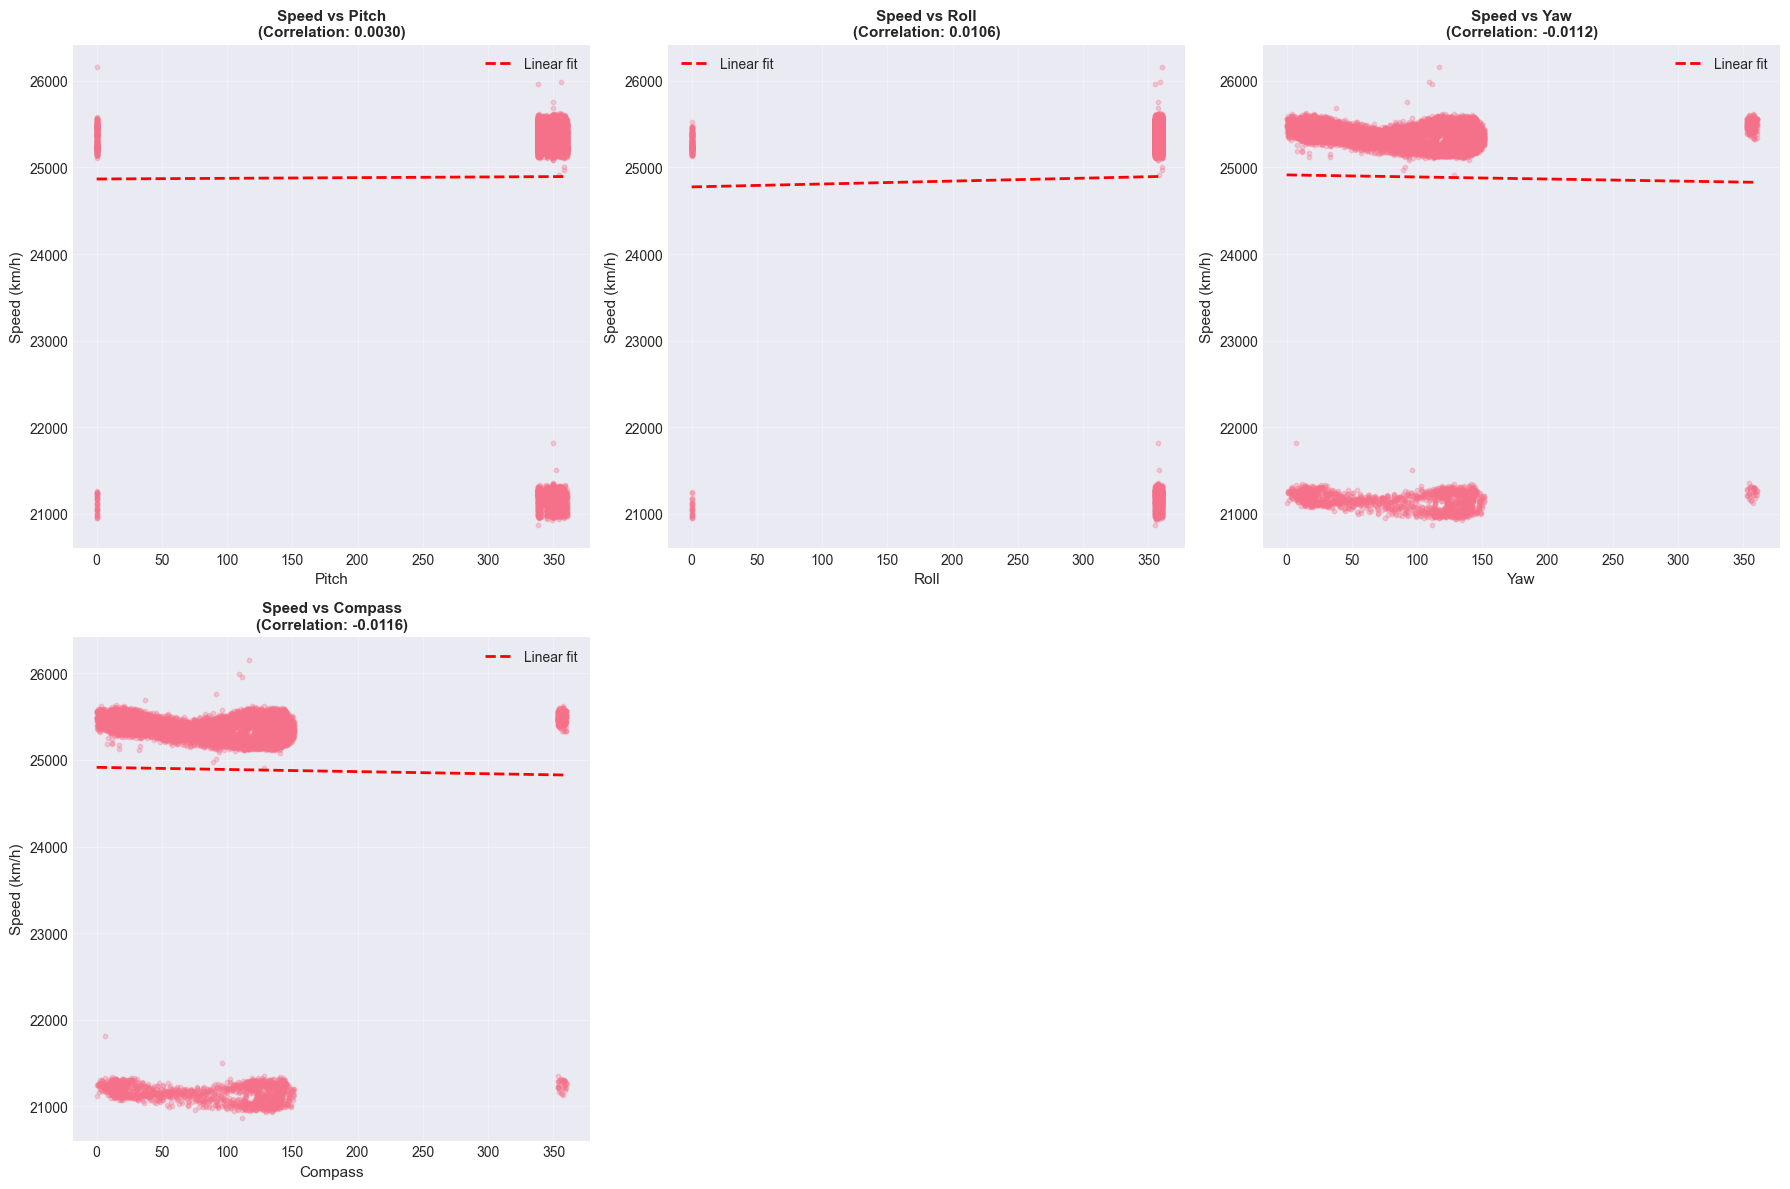

In [14]:
# Plot 11-16: More scatter plots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, meas in enumerate(measurements[6:]):
    ax = axes[idx]
    
    # Create scatter plot
    ax.scatter(df[meas], df['Speed_km_h'], alpha=0.3, s=10)
    
    # Add regression line
    z = np.polyfit(df[meas], df['Speed_km_h'], 1)
    p = np.poly1d(z)
    ax.plot(df[meas].sort_values(), p(df[meas].sort_values()), 
            "r--", linewidth=2, label=f'Linear fit')
    
    # Calculate and display correlation
    corr = df[meas].corr(df['Speed_km_h'])
    ax.set_xlabel(f'{meas}', fontsize=11)
    ax.set_ylabel('Speed (km/h)', fontsize=11)
    ax.set_title(f'Speed vs {meas}\n(Correlation: {corr:.4f})', fontsize=11, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for idx in range(len(measurements[6:]), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

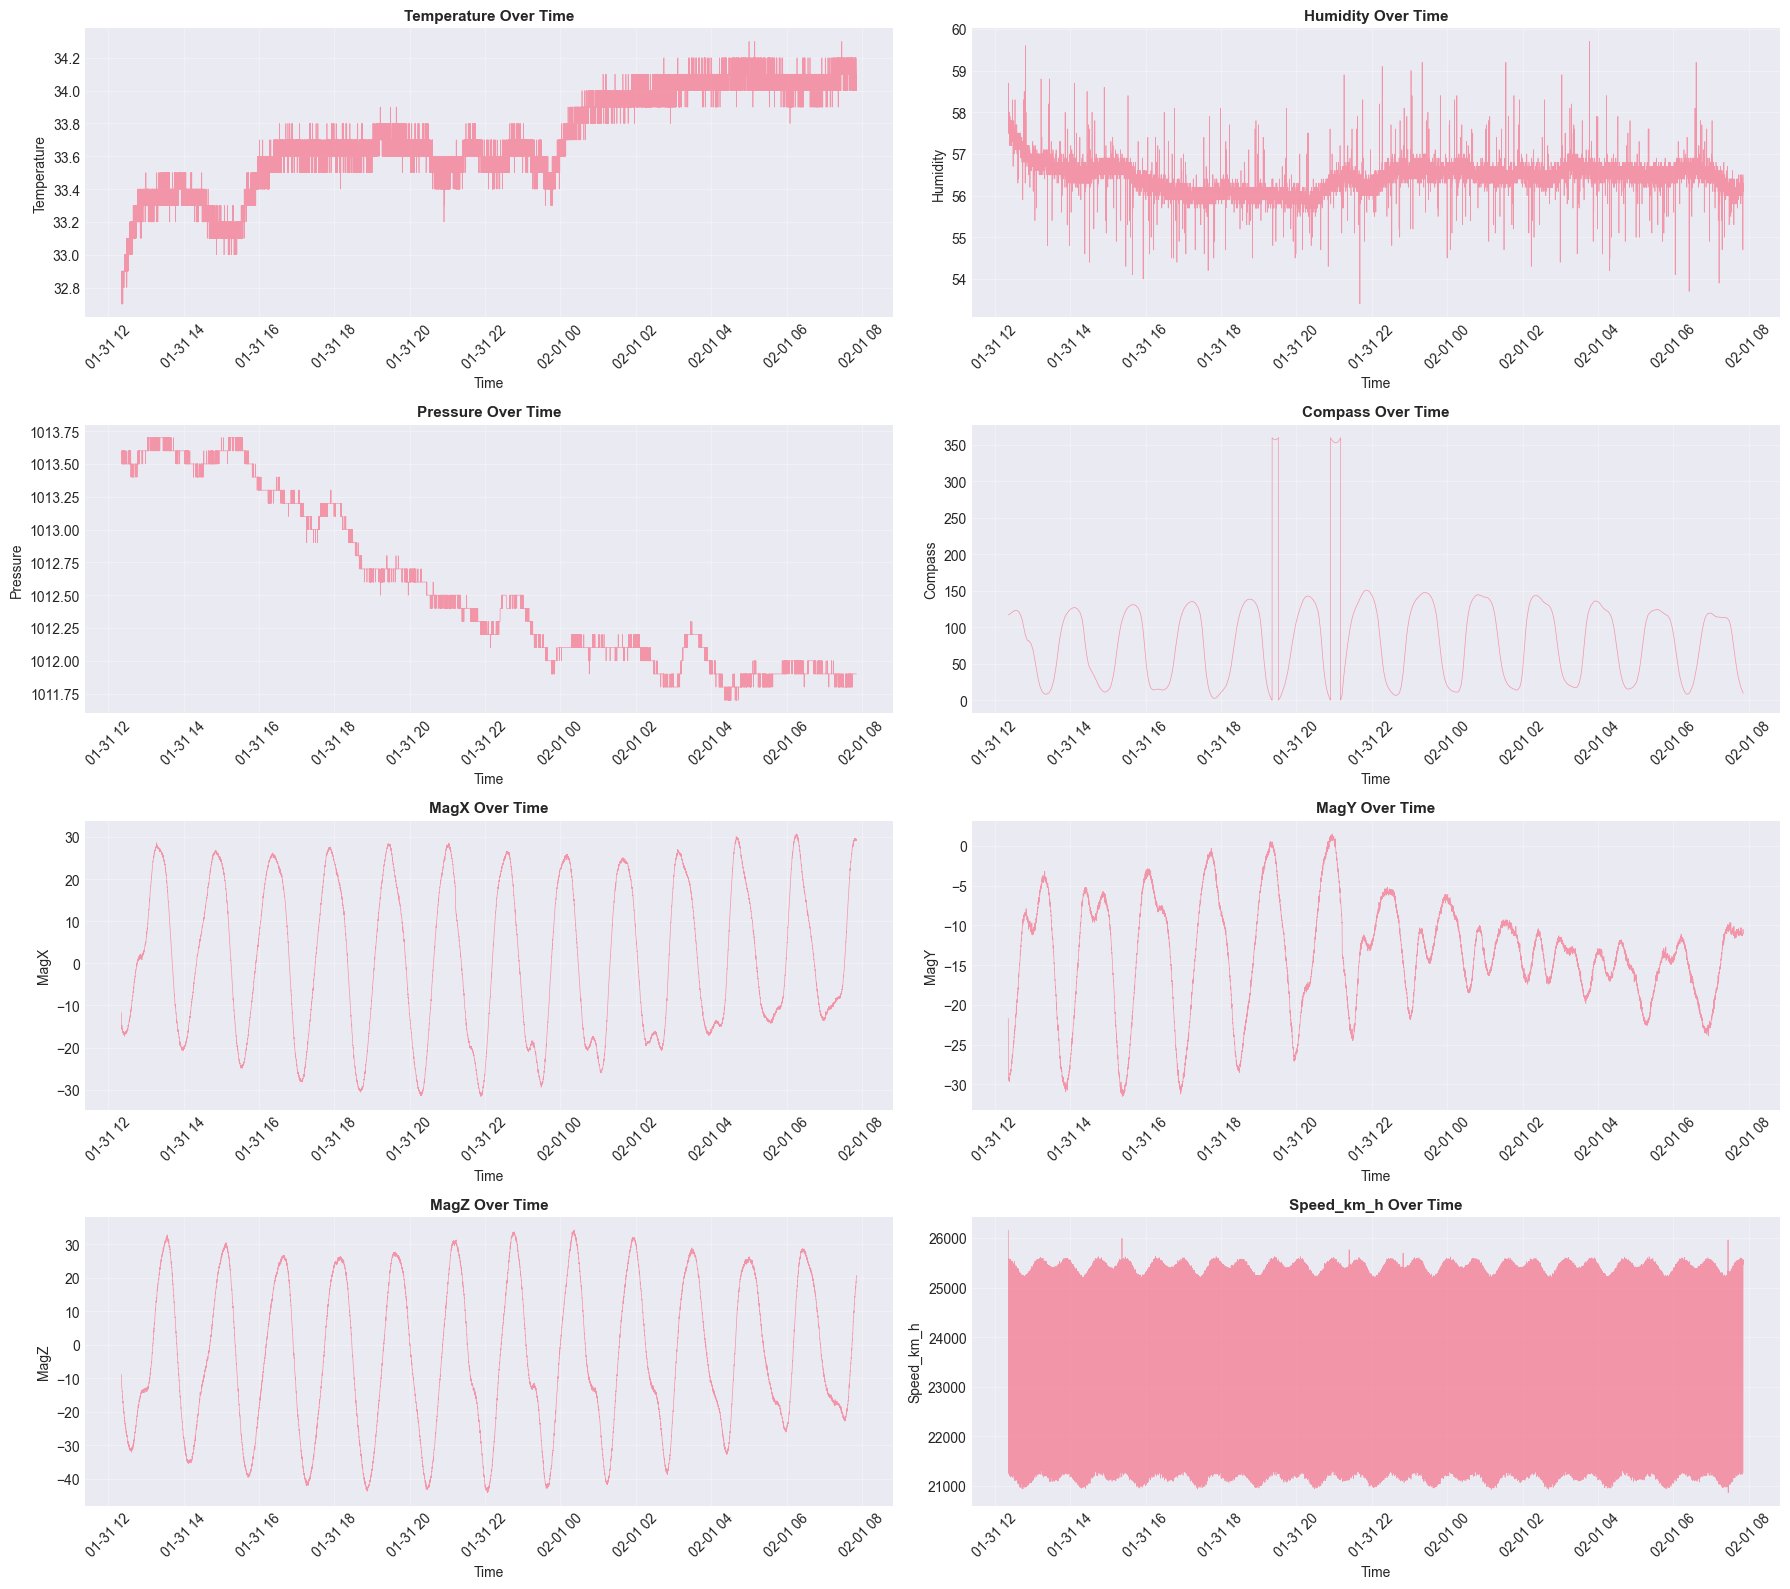

In [15]:
# Plot 17: Time series of all key measurements alongside speed
fig, axes = plt.subplots(4, 2, figsize=(18, 16))

measurements_ts = ['Temperature', 'Humidity', 'Pressure', 'Compass', 
                   'MagX', 'MagY', 'MagZ', 'Speed_km_h']

for idx, meas in enumerate(measurements_ts):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    ax.plot(df['Date/Time'], df[meas], linewidth=0.5, alpha=0.7)
    ax.set_xlabel('Time', fontsize=10)
    ax.set_ylabel(meas, fontsize=10)
    ax.set_title(f'{meas} Over Time', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

** On entry to DLASCL, parameter number  4 had an illegal value
** On entry to DLASCL, parameter number  4 had an illegal value
** On entry to DLASCL, parameter number  4 had an illegal value
** On entry to DLASCL, parameter number  4 had an illegal value
** On entry to DLASCL, parameter number  5 had an illegal value
** On entry to DLASCL, parameter number  4 had an illegal value


LinAlgError: SVD did not converge in Linear Least Squares

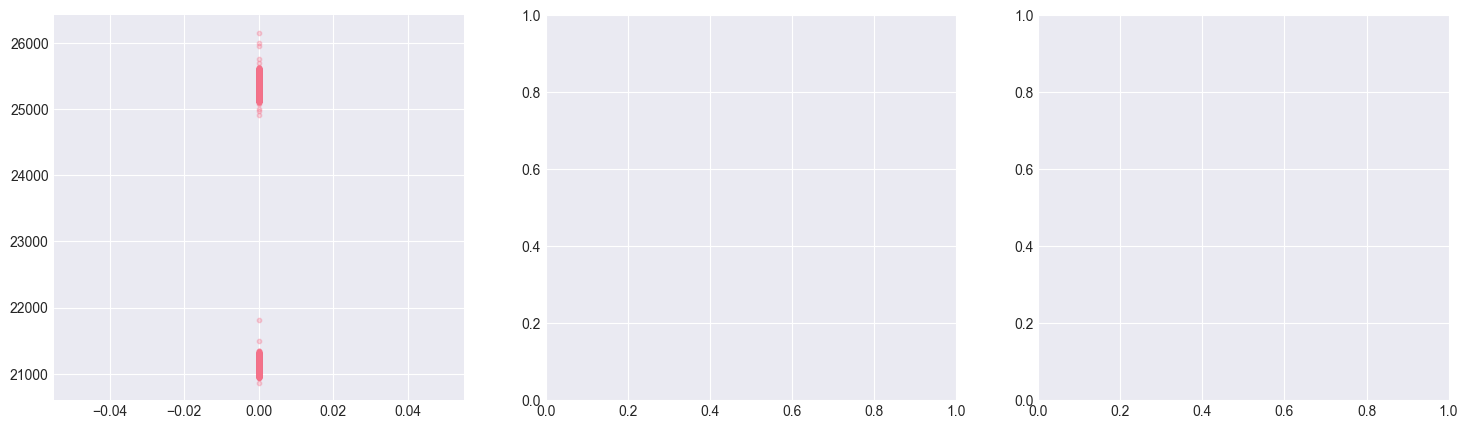

In [16]:
# Plot 18: Speed vs Acceleration components
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

accel_cols = ['AccelX', 'AccelY', 'AccelZ']
for idx, accel in enumerate(accel_cols):
    ax = axes[idx]
    
    ax.scatter(df[accel], df['Speed_km_h'], alpha=0.3, s=10)
    
    # Add regression line
    z = np.polyfit(df[accel], df['Speed_km_h'], 1)
    p = np.poly1d(z)
    ax.plot(df[accel].sort_values(), p(df[accel].sort_values()), 
            "r--", linewidth=2, label=f'Linear fit')
    
    corr = df[accel].corr(df['Speed_km_h'])
    ax.set_xlabel(f'{accel}', fontsize=11)
    ax.set_ylabel('Speed (km/h)', fontsize=11)
    ax.set_title(f'Speed vs {accel}\n(Correlation: {corr:.4f})', fontsize=11, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Plot 19: Speed vs RGB color values
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

color_cols = ['R', 'G', 'B', 'C']
for idx, color in enumerate(color_cols):
    ax = axes[idx]
    
    ax.scatter(df[color], df['Speed_km_h'], alpha=0.3, s=10, c=color.lower() if color != 'C' else 'cyan')
    
    # Add regression line
    z = np.polyfit(df[color], df['Speed_km_h'], 1)
    p = np.poly1d(z)
    ax.plot(df[color].sort_values(), p(df[color].sort_values()), 
            "r--", linewidth=2, label=f'Linear fit')
    
    corr = df[color].corr(df['Speed_km_h'])
    ax.set_xlabel(f'{color} Value', fontsize=11)
    ax.set_ylabel('Speed (km/h)', fontsize=11)
    ax.set_title(f'Speed vs {color}\n(Correlation: {corr:.4f})', fontsize=11, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Plot 20: Calculate magnitude of magnetic field and acceleration
df['Mag_Magnitude'] = np.sqrt(df['MagX']**2 + df['MagY']**2 + df['MagZ']**2)
df['Accel_Magnitude'] = np.sqrt(df['AccelX']**2 + df['AccelY']**2 + df['AccelZ']**2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (meas, title) in enumerate([('Mag_Magnitude', 'Magnetic Field Magnitude'), 
                                      ('Accel_Magnitude', 'Acceleration Magnitude')]):
    ax = axes[idx]
    
    ax.scatter(df[meas], df['Speed_km_h'], alpha=0.3, s=10)
    
    # Add regression line
    z = np.polyfit(df[meas], df['Speed_km_h'], 1)
    p = np.poly1d(z)
    ax.plot(df[meas].sort_values(), p(df[meas].sort_values()), 
            "r--", linewidth=2, label=f'Linear fit')
    
    corr = df[meas].corr(df['Speed_km_h'])
    ax.set_xlabel(title, fontsize=11)
    ax.set_ylabel('Speed (km/h)', fontsize=11)
    ax.set_title(f'Speed vs {title}\n(Correlation: {corr:.4f})', fontsize=11, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Plot 21: Box plots of speed grouped by different measurement ranges
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Create categorical bins for different measurements
measurements_to_bin = ['Temperature', 'Humidity', 'Pressure', 'Compass', 'Mag_Magnitude', 'Motion']

for idx, meas in enumerate(measurements_to_bin):
    ax = axes[idx]
    
    # Create bins
    df[f'{meas}_bin'] = pd.qcut(df[meas], q=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'], duplicates='drop')
    
    # Box plot
    df.boxplot(column='Speed_km_h', by=f'{meas}_bin', ax=ax, grid=False)
    ax.set_title(f'Speed Distribution by {meas} Levels', fontsize=11, fontweight='bold')
    ax.set_xlabel(f'{meas} Level', fontsize=10)
    ax.set_ylabel('Speed (km/h)', fontsize=10)
    ax.get_figure().suptitle('')  # Remove default title

plt.tight_layout()
plt.show()

In [ ]:
# Plot 22: Pair plot for top correlated variables with speed
top_correlated = speed_correlations.abs().nlargest(6).index.tolist()
top_correlated.append('Speed_km_h')

fig = plt.figure(figsize=(16, 16))
sns.pairplot(df[top_correlated], diag_kind='kde', plot_kws={'alpha': 0.3, 's': 10})
plt.suptitle('Pair Plot: Speed vs Top Correlated Measurements', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Plot 23: Rolling correlation over time (to see if correlations change)
window_size = 500  # Number of samples for rolling window

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

top_4_measurements = speed_correlations.abs().nlargest(4).index.tolist()

for idx, meas in enumerate(top_4_measurements):
    ax = axes[idx]
    
    # Calculate rolling correlation
    rolling_corr = df[meas].rolling(window=window_size).corr(df['Speed_km_h'].rolling(window=window_size))
    
    ax.plot(df['Date/Time'], rolling_corr, linewidth=1.5, alpha=0.8)
    ax.set_xlabel('Time', fontsize=10)
    ax.set_ylabel('Rolling Correlation', fontsize=10)
    ax.set_title(f'Rolling Correlation: Speed vs {meas}\n(Window: {window_size} samples)', 
                 fontsize=11, fontweight='bold')
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.grid(True, alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Plot 24: Speed vs Latitude and Longitude separately
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, coord in enumerate(['Latitude', 'Longitude']):
    ax = axes[idx]
    
    ax.scatter(df[coord], df['Speed_km_h'], alpha=0.3, s=10)
    
    # Add regression line
    z = np.polyfit(df[coord], df['Speed_km_h'], 1)
    p = np.poly1d(z)
    ax.plot(df[coord].sort_values(), p(df[coord].sort_values()), 
            "r--", linewidth=2, label=f'Linear fit')
    
    corr = df[coord].corr(df['Speed_km_h'])
    ax.set_xlabel(f'{coord}', fontsize=11)
    ax.set_ylabel('Speed (km/h)', fontsize=11)
    ax.set_title(f'Speed vs {coord}\n(Correlation: {corr:.4f})', fontsize=11, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Plot 25: 3D scatter plot of Speed vs two most correlated measurements
from mpl_toolkits.mplot3d import Axes3D

top_2 = speed_correlations.abs().nlargest(2).index.tolist()

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(df[top_2[0]], df[top_2[1]], df['Speed_km_h'], 
                     c=df['Speed_km_h'], cmap='viridis', s=20, alpha=0.5)

ax.set_xlabel(top_2[0], fontsize=11)
ax.set_ylabel(top_2[1], fontsize=11)
ax.set_zlabel('Speed (km/h)', fontsize=11)
ax.set_title(f'3D Plot: Speed vs {top_2[0]} and {top_2[1]}', fontsize=12, fontweight='bold')
plt.colorbar(scatter, label='Speed (km/h)', shrink=0.8)

plt.tight_layout()
plt.show()

In [ ]:
# Summary statistics and insights
print("="*70)
print("ANALYSIS SUMMARY")
print("="*70)

print(f"\n1. ISS Speed Statistics:")
print(f"   Average Speed: {df['Speed_km_h'].mean():.2f} km/h ({df['Speed_m_s'].mean():.2f} m/s)")
print(f"   Standard Deviation: {df['Speed_km_h'].std():.2f} km/h")
print(f"   Min Speed: {df['Speed_km_h'].min():.2f} km/h")
print(f"   Max Speed: {df['Speed_km_h'].max():.2f} km/h")

print(f"\n2. Top 5 Most Correlated Measurements with Speed:")
for i, (col, corr) in enumerate(speed_correlations.abs().nlargest(5).items(), 1):
    actual_corr = speed_correlations[col]
    direction = "positive" if actual_corr > 0 else "negative"
    print(f"   {i}. {col:15s}: {actual_corr:7.4f} ({direction} correlation)")

print(f"\n3. Top 5 Least Correlated Measurements with Speed:")
for i, (col, corr) in enumerate(speed_correlations.abs().nsmallest(5).items(), 1):
    actual_corr = speed_correlations[col]
    direction = "positive" if actual_corr > 0 else "negative"
    print(f"   {i}. {col:15s}: {actual_corr:7.4f} ({direction} correlation)")

print("\n" + "="*70)

## Key Findings

Based on the comprehensive analysis above, we can identify which measurements show the strongest correlations with ISS speed. This information can be used to:

1. **Predict ISS speed** using sensor measurements
2. **Understand physical relationships** between speed and environmental conditions
3. **Identify anomalies** in the data
4. **Build predictive models** for speed estimation

### Next Steps for Speed Approximation:
- Use the most correlated measurements as features in a regression model
- Consider non-linear relationships (polynomial features)
- Account for time-dependent patterns
- Validate predictions against known ISS orbital mechanics